# Notebook 03 - Régression logistique

**Objectif** : Entraîner le modèle de référence du mémoire (la régression logistique), 
standard historique du scoring de crédit. Ce modèle servira de baseline contre lequel 
comparer Random Forest et XGBoost.

## 0. Imports et chargement des données prétraitées

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-darkgrid')

# Chargement des données prétraitées
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"Train : {X_train.shape[0]:,} lignes × {X_train.shape[1]} colonnes")
print(f"Test  : {X_test.shape[0]:,} lignes × {X_test.shape[1]} colonnes")

Train : 215,254 lignes × 212 colonnes
Test  : 92,253 lignes × 212 colonnes


## 1. Entraînement de la régression logistique

Modèle avec class_weight='balanced' pour compenser le déséquilibre 92/8
et max_iter=1000 pour garantir la convergence.

In [2]:
model_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model_lr.fit(X_train, y_train)

# Prédictions : probabilités (pas les classes)
y_pred_proba = model_lr.predict_proba(X_test)[:, 1]
y_pred_class = model_lr.predict(X_test)

print(f"Nombre de coefficients : {len(model_lr.coef_[0])}")

Nombre de coefficients : 212


## 2. Calcul des métriques

Trois métriques standards du scoring de crédit :
- AUC-ROC : capacité globale à distinguer bons et mauvais clients
- Gini : transformation de l'AUC (Gini = 2 × AUC - 1)
- KS : distance maximale entre les distributions des scores des bons et des mauvais

In [5]:
# AUC-ROC
auc = roc_auc_score(y_test, y_pred_proba)

# Gini
gini = 2 * auc - 1

# KS (Kolmogorov-Smirnov)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
ks = max(tpr - fpr)


print("MÉTRIQUES RÉGRESSION LOGISTIQUE")

print(f"AUC-ROC  : {auc:.4f}")
print(f"Gini     : {gini:.4f}")
print(f"KS       : {ks:.4f}")

MÉTRIQUES RÉGRESSION LOGISTIQUE
AUC-ROC  : 0.7485
Gini     : 0.4970
KS       : 0.3703


## 3. Visualisations

Trois graphiques pour illustrer la performance du modèle :
- Courbe ROC
- Distribution des scores par classe
- Matrice de confusion à seuil 0.5

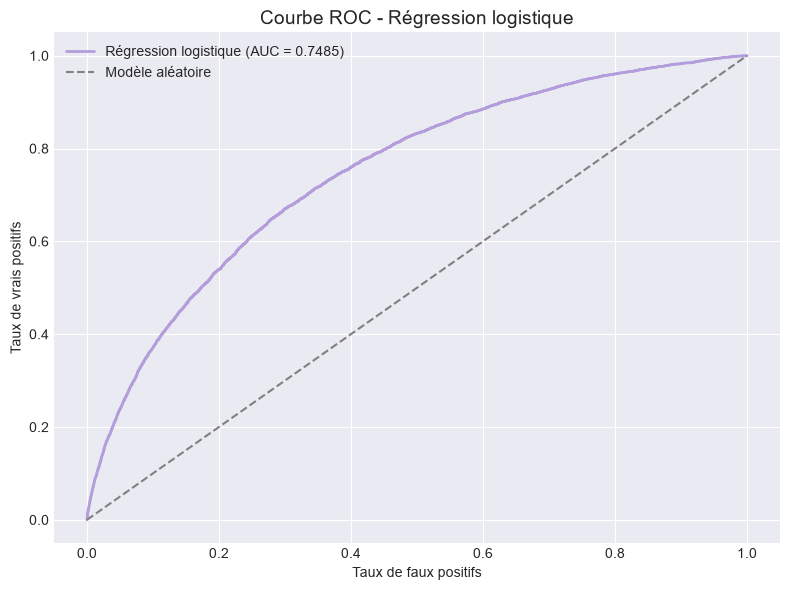

In [8]:
# Courbe ROC
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#B39DDB', linewidth=2, label=f'Régression logistique (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Modèle aléatoire')
ax.set_title("Courbe ROC - Régression logistique", fontsize=14)
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/07_roc_logistique.png", dpi=150, bbox_inches='tight')
plt.show()

La courbe ROC de la régression logistique se situe nettement au-dessus de la 
diagonale (modèle aléatoire), confirmant que le modèle a un pouvoir discriminant 
réel. L'AUC de 0.7485 signifie que si l'on prend au hasard un client ayant fait 
défaut et un client ayant remboursé, le modèle attribue un score de risque plus 
élevé au premier dans 75 % des cas. La courbe montre cependant un aplatissement 
dans la zone centrale (entre 0.3 et 0.6 de taux de faux positifs), ce qui traduit 
une zone d'incertitude où le modèle distingue mal les deux classes. C'est dans 
cette zone que les modèles ML (Random Forest, XGBoost) pourraient apporter un gain.

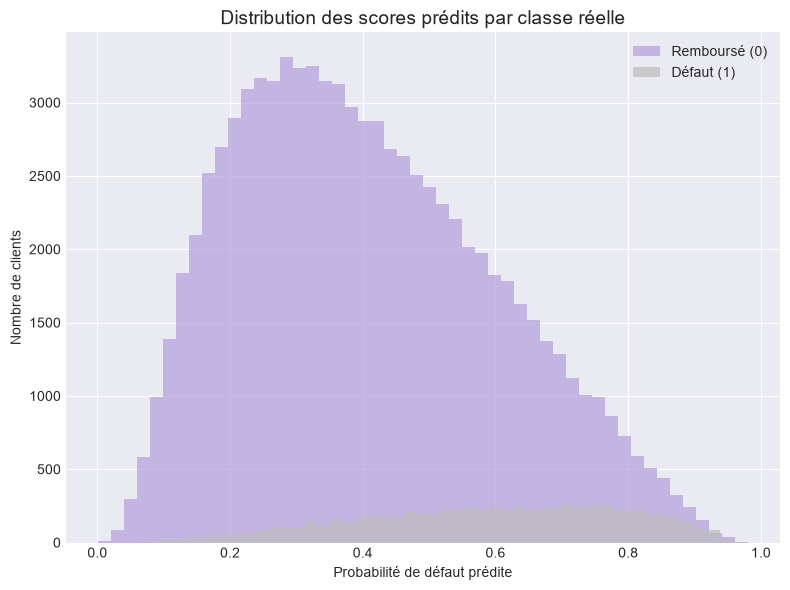

In [7]:
# Distribution des scores par classe
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(y_pred_proba[y_test == 0], bins=50, alpha=0.7, color='#B39DDB', label='Remboursé (0)')
ax.hist(y_pred_proba[y_test == 1], bins=50, alpha=0.7, color='#BDBDBD', label='Défaut (1)')
ax.set_title("Distribution des scores prédits par classe réelle", fontsize=14)
ax.set_xlabel("Probabilité de défaut prédite")
ax.set_ylabel("Nombre de clients")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/08_distribution_scores_logistique.png", dpi=150, bbox_inches='tight')
plt.show()

Les scores des clients remboursés (violet) sont concentrés vers les valeurs 
basses (pic autour de 0.25-0.30), tandis que les scores des clients en défaut 
(gris) sont plus étalés vers la droite. Cependant, le chevauchement entre les 
deux distributions est important (entre 0.3 et 0.7), le modèle ne distingue 
pas clairement les deux classes. Ce chevauchement explique le nombre élevé de 
faux positifs observé dans la matrice de confusion (26 215 clients remboursés 
prédits à tort comme défaillants). Un modèle plus performant (XGBoost) devrait 
séparer davantage ces deux distributions.

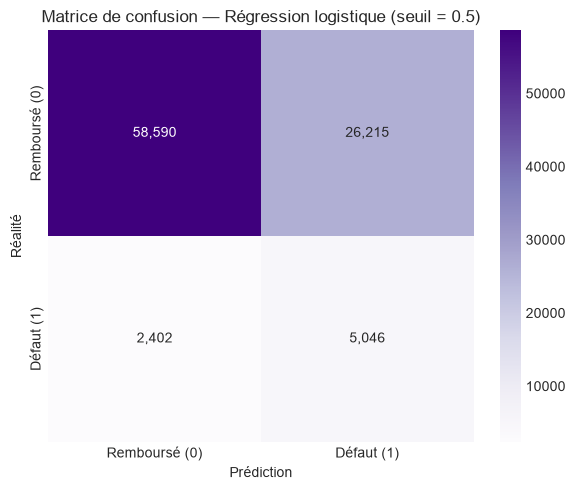

In [9]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_class)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='Purples', ax=ax,
            xticklabels=['Remboursé (0)', 'Défaut (1)'],
            yticklabels=['Remboursé (0)', 'Défaut (1)'])
ax.set_title("Matrice de confusion — Régression logistique (seuil = 0.5)", fontsize=12)
ax.set_xlabel("Prédiction")
ax.set_ylabel("Réalité")

plt.tight_layout()
plt.savefig("../outputs/figures/09_matrice_confusion_logistique.png", dpi=150, bbox_inches='tight')
plt.show()

Le modèle détecte 5 046 des 7 448 défauts réels (rappel de 67,7 %), mais au prix 
de 26 215 faux positifs (des clients remboursés classés à tort comme défaillants). 
C'est l'effet du class_weight='balanced', le modèle privilégie la détection des 
défauts au détriment de la précision. En contexte bancaire, cet arbitrage revient 
à préférer refuser un bon client plutôt que prêter à un mauvais.

## 4. Analyse des coefficients

Les coefficients de la régression logistique permettent une interprétation 
directe. Un coefficient positif augmente la probabilité de défaut, 
un coefficient négatif la diminue. C'est l'interprétabilité native du modèle qui est à comparer avec l'analyse SHAP de XGBoost.

In [10]:
coefficients = pd.Series(model_lr.coef_[0], index=X_train.columns)
top_20 = coefficients.abs().sort_values(ascending=False).head(20)
top_20_signed = coefficients.loc[top_20.index]

print("Top 20 des variables les plus influentes :\n")
for var, coef in top_20_signed.items():
    sens = "↑ risque" if coef > 0 else "↓ risque"
    print(f"  {var:45s} → {coef:+.4f}  ({sens})")

Top 20 des variables les plus influentes :

  FLAG_DOCUMENT_2                               → +1.7634  (↑ risque)
  NAME_INCOME_TYPE_Unemployed                   → +1.3029  (↑ risque)
  ORGANIZATION_TYPE_Trade: type 4               → -1.2196  (↓ risque)
  FLAG_DOCUMENT_15                              → -1.1791  (↓ risque)
  NAME_INCOME_TYPE_Pensioner                    → -1.1638  (↓ risque)
  AMT_GOODS_PRICE                               → -0.9226  (↓ risque)
  NAME_EDUCATION_TYPE_Lower secondary           → +0.8643  (↑ risque)
  AMT_CREDIT                                    → +0.8617  (↑ risque)
  FLAG_DOCUMENT_13                              → -0.8617  (↓ risque)
  FLAG_EMP_PHONE                                → -0.7654  (↓ risque)
  NAME_EDUCATION_TYPE_Secondary / secondary special → +0.7413  (↑ risque)
  FLAG_DOCUMENT_17                              → -0.7303  (↓ risque)
  ORGANIZATION_TYPE_Legal Services              → +0.7298  (↑ risque)
  ORGANIZATION_TYPE_Industry: type 6      

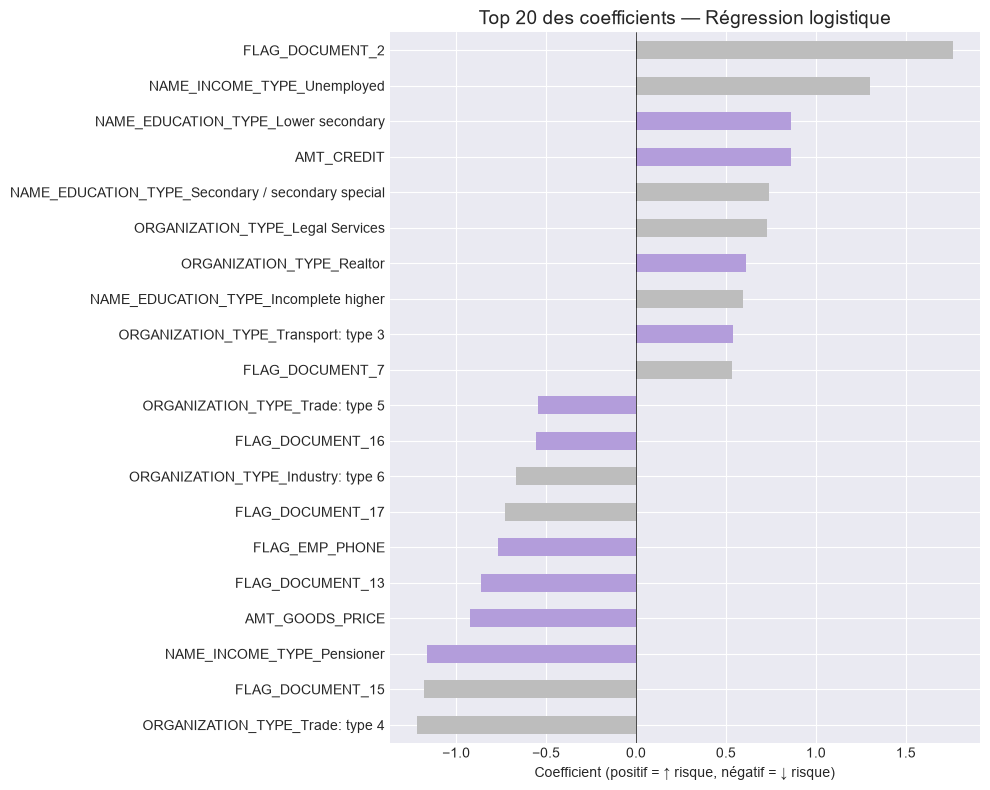

In [11]:
# Visualisation 
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#BDBDBD' if x > 0 else '#B39DDB' for x in top_20_signed]
top_20_signed.sort_values().plot(kind='barh', color=colors, ax=ax)
ax.set_title("Top 20 des coefficients — Régression logistique", fontsize=14)
ax.set_xlabel("Coefficient (positif = ↑ risque, négatif = ↓ risque)")
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig("../outputs/figures/10_coefficients_logistique.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Synthèse et transition

### Résultats de la régression logistique (baseline)

- **AUC-ROC** : 0.7485
- **Gini** : 0.4970
- **KS** : 0.3703

Ces métriques situent le modèle dans la fourchette d'un scoring de crédit 
acceptable en production (Gini entre 0.40 et 0.60, KS > 0.30).

### Observations sur l'interprétabilité

- Chaque variable a un poids, 
  un signe, une magnitude, on peut expliquer chaque décision.
- Les FLAG_DOCUMENT dominent le top 20.
- Les EXT_SOURCE, pourtant très corrélées individuellement avec TARGET, 
  n'apparaissent pas dans le top 20 des coefficients. Effet de la multicolinéarité 
  dans un modèle multivarié (à comparer avec SHAP sur XGBoost).